In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
from typing import List


# import file
movie_list = pd.read_csv('../data/movie_list.csv')


# drop nulls
movie_list_real = movie_list.dropna()

# filter for person 1 picks
collin_picks = movie_list_real[movie_list_real["Chosen By"]=='Collin']

# count_of_collin_picks = collin_picks.count()
count_of_collin_picks = collin_picks.count()

# print("Movies Collin has selected:", count_of_collin_picks)

# count of valerie picks
valerie_picks = movie_list_real[movie_list_real["Chosen By"]=='Valerie']

# print("Movies Valerie has selected:", valerie_picks.count())

# TODO review function to add onto collin picks 
collin_picks = movie_list_real[movie_list_real['Chosen By'].str.contains('Collin', na=False)]
collin_total_counts = len(collin_picks)

print("Number of movies Collin has picked:", collin_total_counts)

val_picks = movie_list_real[movie_list_real['Chosen By'].str.contains('Valerie', na=False)]
val_total_counts = len(val_picks)
print("Number of movies Collin has picked:", val_total_counts)


Number of movies Collin has picked: 85
Number of movies Collin has picked: 85


In [4]:

#mean watched decade

def get_year(date_str: str) -> str:
    return int(str(date_str)[-4:])  # Take the last 4 characters of each date string

# Apply the function to the "Release Date" column
movie_list_real["Release Year"] = movie_list_real["Release Date"].apply(get_year)

# Convert the 'Release Year' column to a single string
rd = movie_list_real["Release Year"].to_string()

# Remove last N characters from the single concatenated string
N = 4
Str2 = rd[-N:]

# Print results
# print("Concatenated Release Dates as String:", rd)
# print("Last 4 characters:", Str2)

#convert str to int for decade floor category 
def get_int(Str2: int) -> int:
        return int(Str2)

md= movie_list_real["Release Year"]

# create decade floor
decade_floor = np.floor(md / 10).astype(int)
movie_list_real["Decades"] = decade_floor * 10

# mean watched decade
mean_watched_decade = movie_list_real.groupby("Decades")["Release Year"].mean().round()
max_decade = mean_watched_decade.idxmax()  # Corrected to find the index (decade) of the max value

print("The mean year per decade is:" , mean_watched_decade)


The mean year per decade is: Decades
1970    1974.0
1980    1984.0
1990    1994.0
2000    2004.0
2010    2015.0
2020    2023.0
Name: Release Year, dtype: float64


C:\Users\19564\AppData\Local\Temp\ipykernel_17868\3521498424.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_list_real["Release Year"] = movie_list_real["Release Date"].apply(get_year)
C:\Users\19564\AppData\Local\Temp\ipykernel_17868\3521498424.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_list_real["Decades"] = decade_floor * 10


The max decade is 2020
the most recent movie is from 2025
the oldest movie is from 1971
The spread of time in years is 54


C:\Users\19564\AppData\Local\Temp\ipykernel_17868\440076963.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valerie_picks["Decades"] = decades
C:\Users\19564\AppData\Local\Temp\ipykernel_17868\440076963.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collin_picks["Decades"] = decades


Text(0.5, 1.0, 'Collin Decade Breakdown')

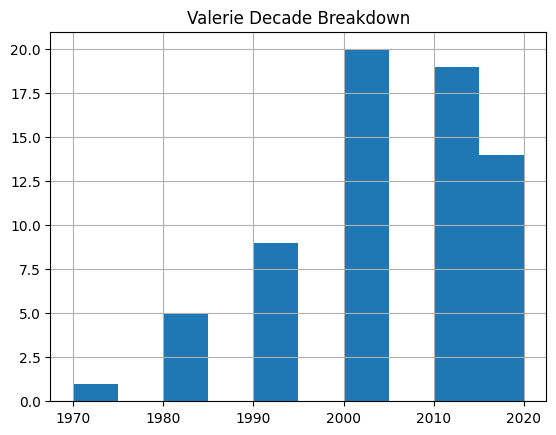

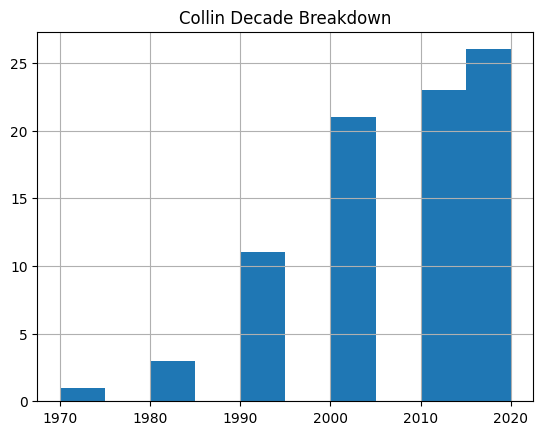

In [5]:
# decade breakdown 

# max decade
print("The max decade is",  max_decade)

oldest = movie_list_real["Release Year"].min()
recent = movie_list_real["Release Year"].max()

# oldest_movie
print("the most recent movie is from",recent )
print("the oldest movie is from", oldest)

# time spread
time_diff =  recent-oldest
print("The spread of time in years is", time_diff)

#v most watched decade 

decades = movie_list_real["Decades"]
valerie_picks["Decades"] = decades

release_date_decades = valerie_picks[["Release Date", "Decades", "Chosen By"]]

release_date_decades.groupby("Decades").count()

release_date_decades.hist()

plt.title("Valerie Decade Breakdown")

#c most watched decade 
collin_picks["Decades"] = decades

release_date_decades = collin_picks[["Release Date", "Decades", "Chosen By"]]

release_date_decades.groupby("Decades").count()

release_date_decades.hist()
plt.title("Collin Decade Breakdown")




Decades
2020    52
2010    45
2000    42
1990    22
1980     9
1970     2
Name: count, dtype: int64

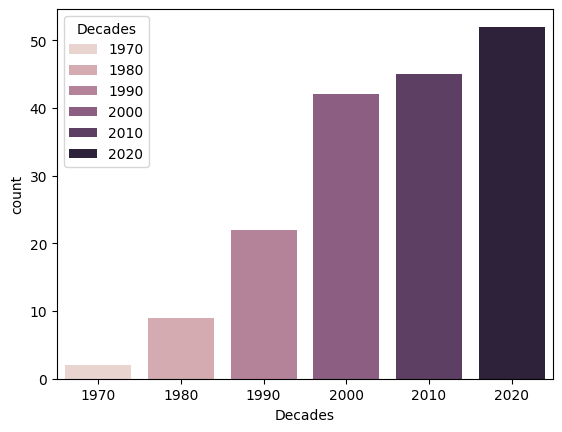

In [6]:
#  plot of decades watched

sns.countplot(x= movie_list_real["Decades"], hue = movie_list_real["Decades"])

movie_list_real["Decades"].value_counts()

# g = sns.catplot(x=movie_list_real["Decades"], kind='count', data=movie_list_real, hue=movie_list_real["Decades"])
# for ax in g.axes.flat:
#     ax.bar_label(ax.containers[0])




C:\Users\19564\AppData\Local\Temp\ipykernel_17868\2887851183.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels = list , rotation=60,)


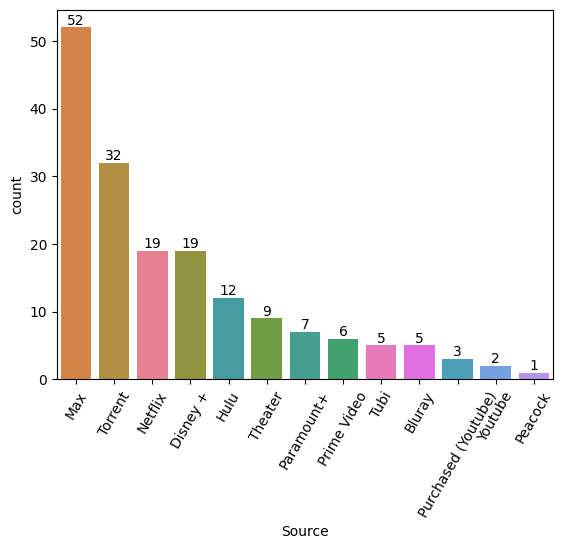

In [7]:
# # Count Plot of Movie Sources 
m= movie_list_real["Source"].value_counts()
m

movie_sources = (movie_list_real["Source"])
list = []

for val in movie_sources:
    if val not in list:
        list.append(val)

g= sns.countplot(data=movie_list_real, x = movie_list_real["Source"], hue = movie_list_real["Source"],  order = movie_list_real['Source'].value_counts().index)
g.set_xticklabels(labels = list , rotation=60,)

for container in g.containers:
    g.bar_label(container)
plt.show()

<Axes: title={'center': 'Movie Picks Per Person'}, ylabel='Chosen By'>

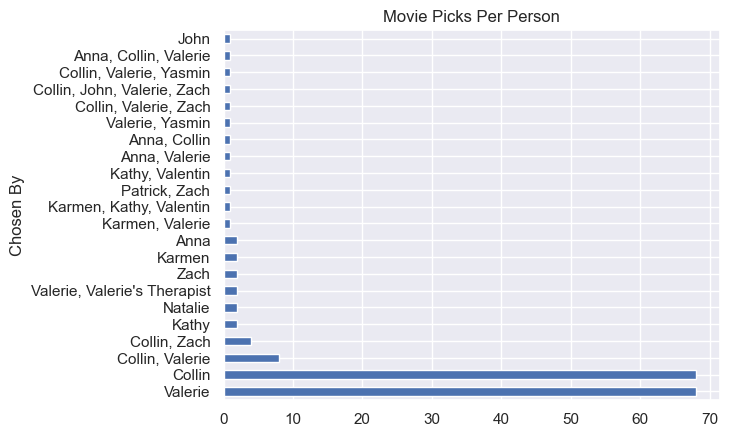

In [8]:
# Histogram of picks per person
sns.set_theme(style="darkgrid")
# sns.histplot(data = movie_list_real, y= movie_list_real["Chosen By"], )
movie_list_real["Chosen By"].value_counts().plot(kind='barh', y= movie_list_real["Chosen By"], title = "Movie Picks Per Person")

# ax = sns.countplot(x=movie_list_real["Chosen By"], data=movie_list_real)
# ax.bar_label(ax.containers[0])
# ax.set_xticklabels(labels = movie_list_real["Chosen By"] , rotation=45) 
# plt.xticks(fontsize=8)

C:\Users\19564\AppData\Local\Temp\ipykernel_17868\937496323.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels = movie_list_real["Completed"] , rotation=90)


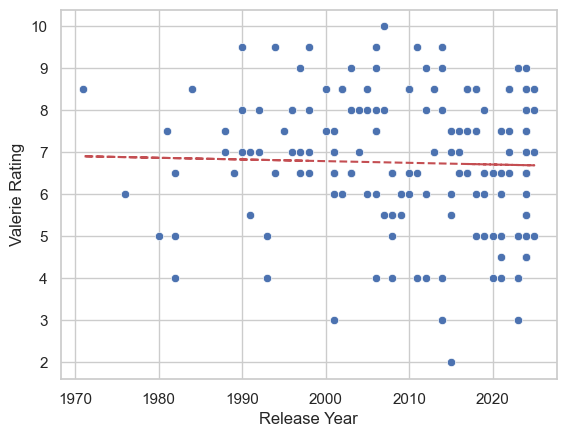

In [9]:
# Release Year and Ratings Scatter Plot

# define variables for ratings
c_rating = movie_list_real["Collin Rating"]
v_rating = movie_list_real["Valerie Rating"]


# movie_list_real
x=movie_list_real["Release Year"]
y= c_rating

# scatter plot
sns.set(style='whitegrid') 
sns.scatterplot(x=movie_list_real["Release Year"],
                    y=v_rating,
                    data=movie_list_real)
g.set_xticklabels(labels = movie_list_real["Completed"] , rotation=90) 
 

# trendline
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "r--")  # 'r--' is for a red dashed line
# movie_list_real

In [10]:
# ASK FOR HELP, NEED TO TALK THROUGH

#  mean rating per genre for collin
movie_list_real["genre_mean"] = movie_list_real.groupby("Genre")["Collin Rating"].transform(lambda x: x.mean())
print(movie_list_real[["Genre","genre_mean"]].value_counts(ascending=False))


# seperate genre categories TODO
# split string to get single values

movie_list_real["Genre"].value_counts()

movie_genre = str(movie_list_real["Genre"])

string = movie_genre
words = string.split(',')

genre_dict = {} # maps genre -> number of movies with that genre

for val in words:
    if val not in genre_dict:
        genre_dict[val] = 1
    else:
        genre_dict[val] += 1

print(genre_dict)
genre_dict


# first for loop to iterate over each title
for elem in movie_list_real:
    movie_list_real["Genre"].apply(words)
for elem in words:
    if elem not in genre_dict:
        genre_dict[val] = 1
    else:
        genre_dict[val] += 1


C:\Users\19564\AppData\Local\Temp\ipykernel_17868\3805250503.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_list_real["genre_mean"] = movie_list_real.groupby("Genre")["Collin Rating"].transform(lambda x: x.mean())


Genre                                 genre_mean
Comedy                                6.423077      26
Comedy, Family                        6.818182      22
Comedy, Drama                         7.222222       9
Drama                                 7.500000       8
Horror, Thriller                      7.857143       7
Horror                                6.214286       7
Action                                6.300000       5
Family, Musical                       7.400000       5
Comedy, Stoner                        6.300000       5
Action, Comedy                        6.125000       4
Adventure, Comedy, Family             6.875000       4
Comedy, Romance                       6.250000       4
Drama, Musical                        8.000000       3
Drama, Family                         6.166667       3
Comedy, Musical                       5.500000       3
Action, Family                        5.333333       3
Christmas, Comedy                     6.333333       3
Christmas, Comed

AttributeError: '1                              Horror
3                              Comedy
5      Biography' is not a valid function for 'Series' object

In [ ]:
# exploring outliers
print(movie_list_real["Completed"].describe())


count                172
unique               163
top       March 22, 2025
freq                   2
Name: Completed, dtype: object


In [ ]:
# select movie list title where valerie rating = 10 TODO update with a grouby 
# for elem in movie_list_real:
#     print("Valerie rated", movie_list_real["Name"],v_rating.head(10))

# higest rated movie v
rated_10 = movie_list_real[movie_list_real["Valerie Rating"]==10]
print("Valerie's number one movie:\n", rated_10[["Name","Valerie Rating"]])


# lowest rated movies v
low_rating = movie_list_real[movie_list_real["Valerie Rating"]< 4]
print("Valerie's lowest ratings:\n ", low_rating["Name"])


Valerie's number one movie:
             Name  Valerie Rating
169  Ratatouille            10.0
Valerie's lowest ratings:
  47              How High
55            Joe Dirt 2
101          Poor Things
139    Horrible Bosses 2
Name: Name, dtype: object


In [ ]:
# higest rated movie c
rated_10 = movie_list_real[movie_list_real["Collin Rating"]==9]
print("Collin's number one movie:\n", rated_10[["Name","Collin Rating"]])


# lowest rated movies c
low_rating = movie_list_real[movie_list_real["Collin Rating"]< 4]
print("Collin's lowest ratings:\n ", low_rating["Name"])

Collin's number one movie:
               Name  Collin Rating
75        Bird Box            9.0
124  Billy Madison            9.0
144     Dreamgirls            9.0
155       Whiplash            9.0
Collin's lowest ratings:
  38                   God Bless America
47                            How High
55                          Joe Dirt 2
71                           Annabelle
101                        Poor Things
165    Garfield: A Tail of Two Kitties
Name: Name, dtype: object


C:\Users\19564\AppData\Local\Temp\ipykernel_2940\3144963881.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(labels = movie_list_real["Completed"] , rotation=90)


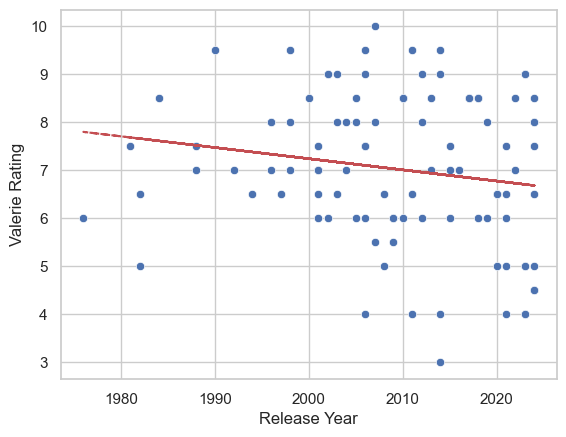

In [ ]:

# movie_list_real
x=movie_list_real["Release Year"]
y= v_rating

# scatter plot
sns.set(style='whitegrid') 
sns.scatterplot(x=movie_list_real["Release Year"],
                    y=v_rating,
                    data=movie_list_real)
g.set_xticklabels(labels = movie_list_real["Completed"] , rotation=90) 
 

# trendline
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "r--")  # 'r--' is for a red dashed line



In [12]:
# CORRELATION GENRE V RATING
# need single worded genre
# list with single word genre
results = []

# Iterate through each row in the DataFrame
for index, row in movie_list_real.iterrows():
    # Split genres and append each to results
    for genre in row["Genre"].split(","):
        results.append(genre.strip())  # Clean up extra spaces


# create DF from results list
genre_list = df = pd.DataFrame(data=results)

# Add each val to the new list if it doesn't already exist
for val in genre_list:
    if val not in results:
        results.append(val)

# remove duplicates
genre_list.drop_duplicates()


# count of single genres
genre_counts =genre_list.value_counts()


# # Print the genres list
print("Genres List:", genre_counts)



Genres List: 0            
Comedy           99
Family           47
Drama            33
Horror           20
Action           19
Musical          16
Thriller         13
Adventure        13
Romance          10
Christmas         8
Stoner            5
Bizarro           5
Superhero         5
Slice of Life     4
Classic           4
Mystery           4
Documentary       3
Biography         1
Arthouse          1
Sci-Fi            1
Sports            1
Name: count, dtype: int64


                                          mean    sum  count
Genre                                                       
Action                                6.300000   31.5      5
Action, Adventure, Family, Superhero  8.000000    8.0      1
Action, Adventure, Superhero          6.000000    6.0      1
Action, Christmas, Thriller           7.500000    7.5      1
Action, Comedy                        6.125000   24.5      4
Action, Comedy, Family                8.500000    8.5      1
Action, Comedy, Superhero             7.500000   15.0      2
Action, Family                        5.333333   16.0      3
Action, Musical                       6.500000    6.5      1
Adventure                             6.000000   12.0      2
Adventure, Comedy, Family             6.875000   27.5      4
Adventure, Comedy, Horror             6.000000    6.0      1
Adventure, Comedy, Superhero          8.000000    8.0      1
Adventure, Family                     7.750000   15.5      2
Adventure, Family, Sci-F

C:\Users\19564\AppData\Local\Temp\ipykernel_17868\3918495415.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(labels = movie_list_real["Genre"] , rotation=45,)


[Text(0, 0, 'Horror'),
 Text(1, 0, 'Comedy'),
 Text(2, 0, 'Biography, Documentary, Family'),
 Text(3, 0, 'Action, Musical'),
 Text(4, 0, 'Action, Adventure, Superhero'),
 Text(5, 0, 'Thriller'),
 Text(6, 0, 'Comedy'),
 Text(7, 0, 'Comedy, Thriller'),
 Text(8, 0, 'Action, Adventure, Family, Superhero'),
 Text(9, 0, 'Comedy, Drama'),
 Text(10, 0, 'Horror, Thriller'),
 Text(11, 0, 'Action, Comedy'),
 Text(12, 0, 'Horror, Thriller'),
 Text(13, 0, 'Adventure, Family, Sci-Fi'),
 Text(14, 0, 'Horror'),
 Text(15, 0, 'Comedy, Mystery'),
 Text(16, 0, 'Action'),
 Text(17, 0, 'Comedy, Family'),
 Text(18, 0, 'Comedy, Romance'),
 Text(19, 0, 'Comedy, Family'),
 Text(20, 0, 'Adventure, Comedy, Family'),
 Text(21, 0, 'Comedy, Family'),
 Text(22, 0, 'Classic, Comedy, Romance'),
 Text(23, 0, 'Drama, Slice of Life'),
 Text(24, 0, 'Horror, Thriller'),
 Text(25, 0, 'Comedy, Musical'),
 Text(26, 0, 'Horror, Mystery'),
 Text(27, 0, 'Action'),
 Text(28, 0, 'Action, Comedy'),
 Text(29, 0, 'Drama, Horror'),
 Te

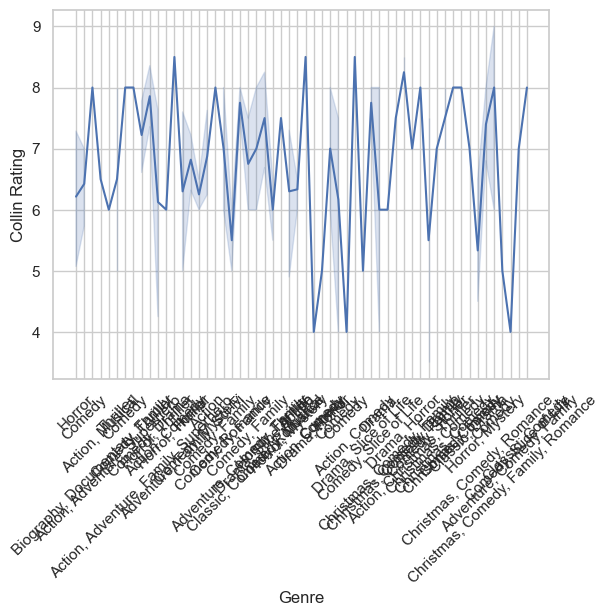

In [27]:
# rating per genre 
# find mean of c_rating per genre


# count of records per genre
genre_info = pd.DataFrame(data=genre_counts, columns= ['Genre', 'Counts'])

genre_info


# find mean of c_rating per genre
# sum of scores per genre / count of genre 

# for every movie in movie_list_real, take the genre and rating, add the ratings and divide by genre_Count

rating_list = []

for index, row in movie_list_real.iterrows():
    rating_list.append(row["Collin Rating"])

rating_list


# # NEED NEW COLUMN, GENRE SUMS
# comedy_counts = movie_list_real[movie_list_real['Genre'].str.contains('Comedy', na=False)].count()

# # empty list
# comedy_floats = []

# # for loop to add items
# for elem in movie_list_real["Genre"] == "Comedy":
#     comedy_floats.append(movie_list_real["Collin Rating"])



# Grouped DF w/ collin rating agg functions
grouped_df = movie_list_real.groupby("Genre")['Collin Rating'].agg(['mean', 'sum', 'count'])
print(grouped_df)
b = sns.lineplot(grouped_df, x=movie_list_real['Genre'], y= movie_list_real['Collin Rating'])
b.set_xticklabels(labels = movie_list_real["Genre"] , rotation=45,)

# movie_list_real.join(genre_info, on ='Genre', how = "left", lsuffix='_mlr', rsuffix = '_genreinfo')